### Loading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\MidhunWork\DSA 2026 files\Asngmnt_Case_study_Unsup_learn\Wine_clust.csv")


In [2]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
df.shape

(178, 13)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [5]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
df.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [7]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Alcohol: 126 unique values
Malic_Acid: 133 unique values
Ash: 79 unique values
Ash_Alcanity: 63 unique values
Magnesium: 53 unique values
Total_Phenols: 97 unique values
Flavanoids: 132 unique values
Nonflavanoid_Phenols: 39 unique values
Proanthocyanins: 101 unique values
Color_Intensity: 132 unique values
Hue: 78 unique values
OD280: 122 unique values
Proline: 121 unique values


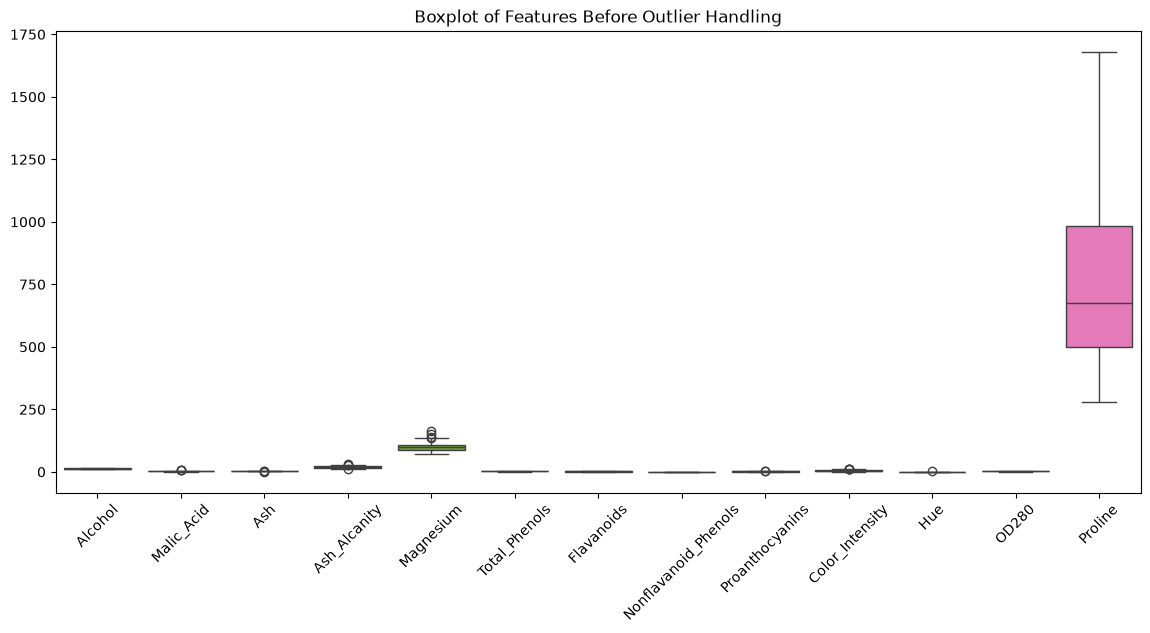

In [8]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title('Boxplot of Features Before Outlier Handling')
plt.show()


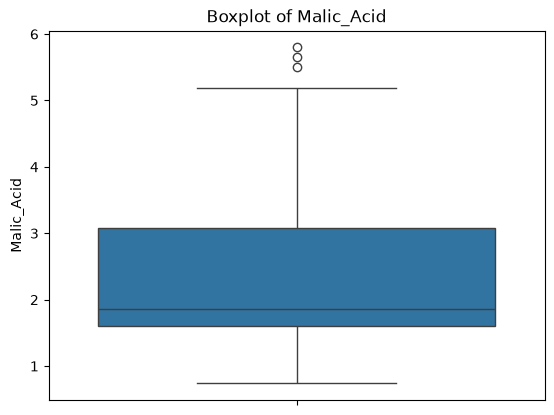

In [9]:
sns.boxplot(df['Malic_Acid'])
plt.title('Boxplot of Malic_Acid')
plt.show()

In [10]:
Q1 = np.percentile(df['Malic_Acid'], 25)
Q2 = np.percentile(df['Malic_Acid'], 50)
Q3 = np.percentile(df['Malic_Acid'], 75)
IQR = Q3 - Q1

low_lim = Q1 - 1.5 * IQR
upr_lim = Q3 + 1.5 * IQR

outliers = []
for x in df['Malic_Acid']:
    if x < low_lim or x > upr_lim:
        outliers.append(x)

In [11]:
len(outliers)

3

In [12]:
if len(outliers) > 0:
    print(max(outliers))
    print(min(outliers))

5.8
5.51


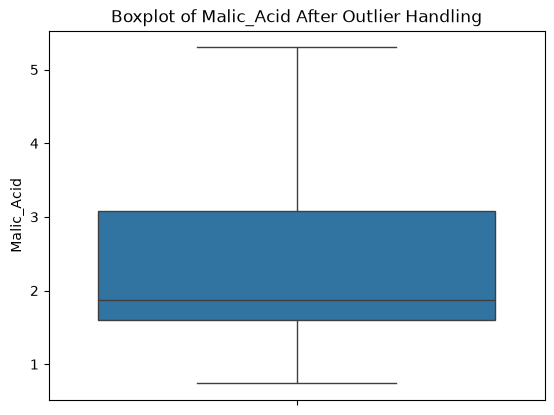

In [13]:
df['Malic_Acid'] = df['Malic_Acid'].clip(lower=low_lim, upper=upr_lim)
sns.boxplot(df['Malic_Acid'])
plt.title('Boxplot of Malic_Acid After Outlier Handling')
plt.show()

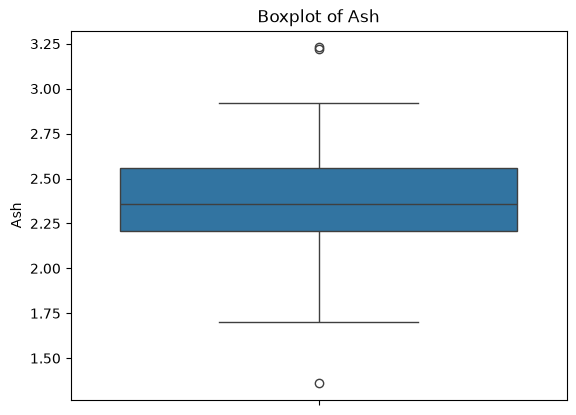

In [14]:
sns.boxplot(df['Ash'])
plt.title('Boxplot of Ash')
plt.show()

In [15]:
Q1 = np.percentile(df['Ash'], 25)
Q2 = np.percentile(df['Ash'], 50)
Q3 = np.percentile(df['Ash'], 75)
IQR = Q3 - Q1

low_lim = Q1 - 1.5 * IQR
upr_lim = Q3 + 1.5 * IQR

outliers = []
for x in df['Ash']:
    if x < low_lim or x > upr_lim:
        outliers.append(x)

In [16]:
len(outliers)

3

In [17]:
if len(outliers) > 0:
    print(max(outliers))
    print(min(outliers))

3.23
1.36


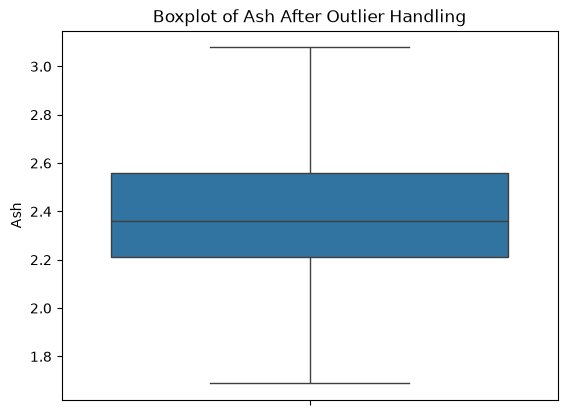

In [18]:
df['Ash'] = df['Ash'].clip(lower=low_lim, upper=upr_lim)
sns.boxplot(df['Ash'])
plt.title('Boxplot of Ash After Outlier Handling')
plt.show()

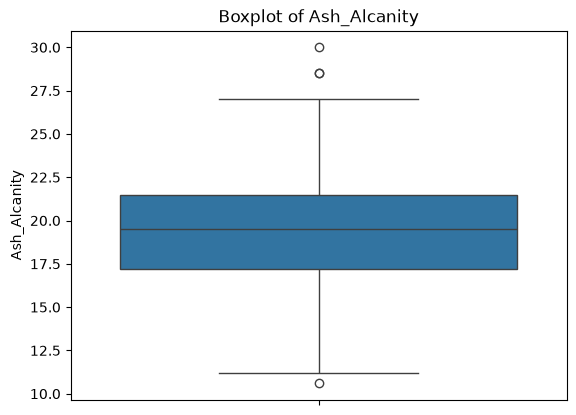

In [19]:
sns.boxplot(df['Ash_Alcanity'])
plt.title('Boxplot of Ash_Alcanity')
plt.show()

In [20]:
Q1 = np.percentile(df['Ash_Alcanity'], 25)
Q2 = np.percentile(df['Ash_Alcanity'], 50)
Q3 = np.percentile(df['Ash_Alcanity'], 75)
IQR = Q3 - Q1

low_lim = Q1 - 1.5 * IQR
upr_lim = Q3 + 1.5 * IQR

outliers = []
for x in df['Ash_Alcanity']:
    if x < low_lim or x > upr_lim:
        outliers.append(x)

In [21]:
len(outliers)

4

In [22]:
if len(outliers) > 0:
    print(max(outliers))
    print(min(outliers))

30.0
10.6


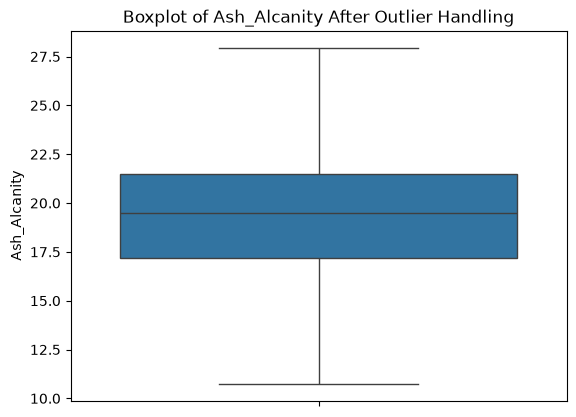

In [23]:
df['Ash_Alcanity'] = df['Ash_Alcanity'].clip(lower=low_lim, upper=upr_lim)
sns.boxplot(df['Ash_Alcanity'])
plt.title('Boxplot of Ash_Alcanity After Outlier Handling')
plt.show()

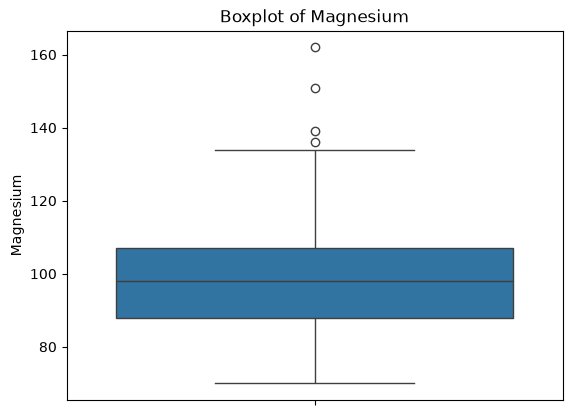

In [24]:
sns.boxplot(df['Magnesium'])
plt.title('Boxplot of Magnesium')
plt.show()

In [25]:
Q1 = np.percentile(df['Magnesium'], 25)
Q2 = np.percentile(df['Magnesium'], 50)
Q3 = np.percentile(df['Magnesium'], 75)
IQR = Q3 - Q1

low_lim = Q1 - 1.5 * IQR
upr_lim = Q3 + 1.5 * IQR

outliers = []
for x in df['Magnesium']:
    if x < low_lim or x > upr_lim:
        outliers.append(x)

In [26]:
len(outliers)

4

In [27]:
if len(outliers) > 0:
    print(max(outliers))
    print(min(outliers))

162
136


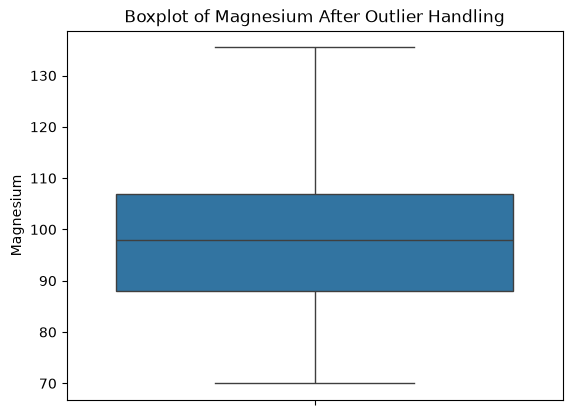

In [28]:
df['Magnesium'] = df['Magnesium'].clip(lower=low_lim, upper=upr_lim)
sns.boxplot(df['Magnesium'])
plt.title('Boxplot of Magnesium After Outlier Handling')
plt.show()

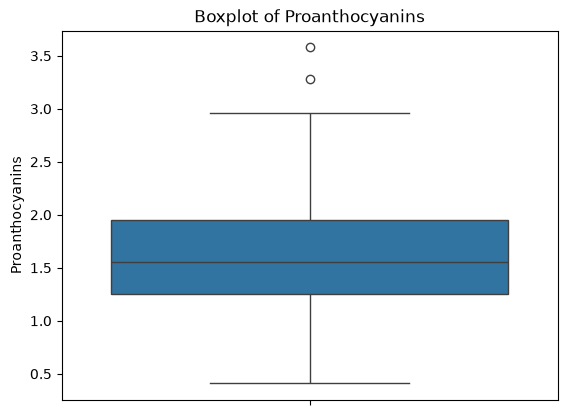

In [29]:
sns.boxplot(df['Proanthocyanins'])
plt.title('Boxplot of Proanthocyanins')
plt.show()

In [30]:
Q1 = np.percentile(df['Proanthocyanins'], 25)
Q2 = np.percentile(df['Proanthocyanins'], 50)
Q3 = np.percentile(df['Proanthocyanins'], 75)
IQR = Q3 - Q1

low_lim = Q1 - 1.5 * IQR
upr_lim = Q3 + 1.5 * IQR

outliers = []
for x in df['Proanthocyanins']:
    if x < low_lim or x > upr_lim:
        outliers.append(x)

In [31]:
len(outliers)

2

In [32]:
if len(outliers) > 0:
    print(max(outliers))
    print(min(outliers))

3.58
3.28


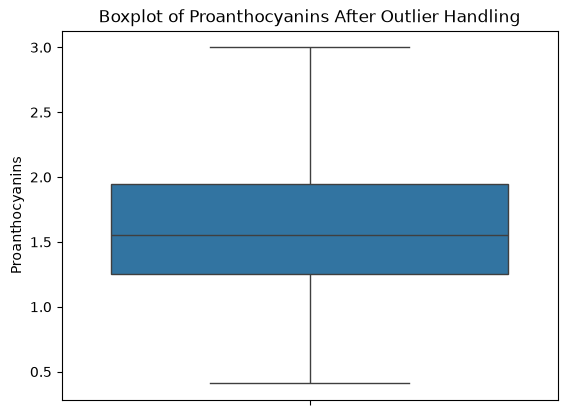

In [33]:
df['Proanthocyanins'] = df['Proanthocyanins'].clip(lower=low_lim, upper=upr_lim)
sns.boxplot(df['Proanthocyanins'])
plt.title('Boxplot of Proanthocyanins After Outlier Handling')
plt.show()

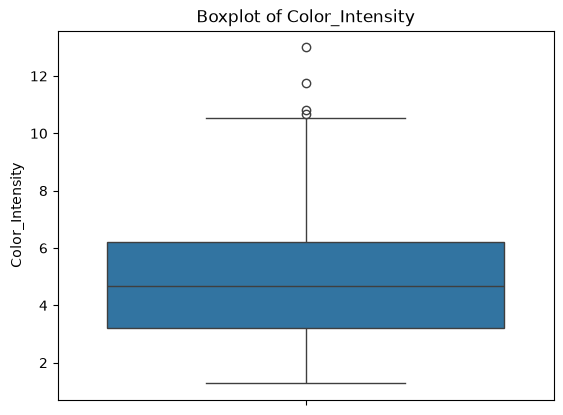

In [34]:
sns.boxplot(df['Color_Intensity'])
plt.title('Boxplot of Color_Intensity')
plt.show()

In [35]:
Q1 = np.percentile(df['Color_Intensity'], 25)
Q2 = np.percentile(df['Color_Intensity'], 50)
Q3 = np.percentile(df['Color_Intensity'], 75)
IQR = Q3 - Q1

low_lim = Q1 - 1.5 * IQR
upr_lim = Q3 + 1.5 * IQR

outliers = []
for x in df['Color_Intensity']:
    if x < low_lim or x > upr_lim:
        outliers.append(x)

In [36]:
len(outliers)

4

In [37]:
if len(outliers) > 0:
    print(max(outliers))
    print(min(outliers))

13.0
10.68


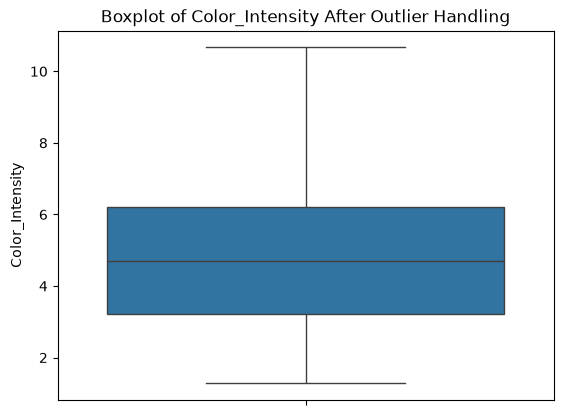

In [38]:
df['Color_Intensity'] = df['Color_Intensity'].clip(lower=low_lim, upper=upr_lim)
sns.boxplot(df['Color_Intensity'])
plt.title('Boxplot of Color_Intensity After Outlier Handling')
plt.show()

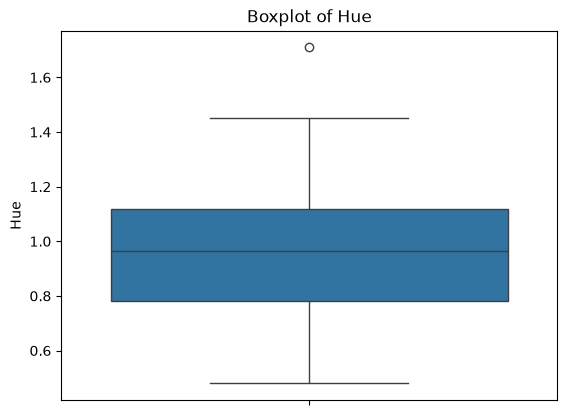

In [39]:
sns.boxplot(df['Hue'])
plt.title('Boxplot of Hue')
plt.show()

In [40]:
Q1 = np.percentile(df['Hue'], 25)
Q2 = np.percentile(df['Hue'], 50)
Q3 = np.percentile(df['Hue'], 75)
IQR = Q3 - Q1

low_lim = Q1 - 1.5 * IQR
upr_lim = Q3 + 1.5 * IQR

outliers = []
for x in df['Hue']:
    if x < low_lim or x > upr_lim:
        outliers.append(x)

In [41]:
len(outliers)

1

In [42]:
if len(outliers) > 0:
    print(max(outliers))
    print(min(outliers))

1.71
1.71


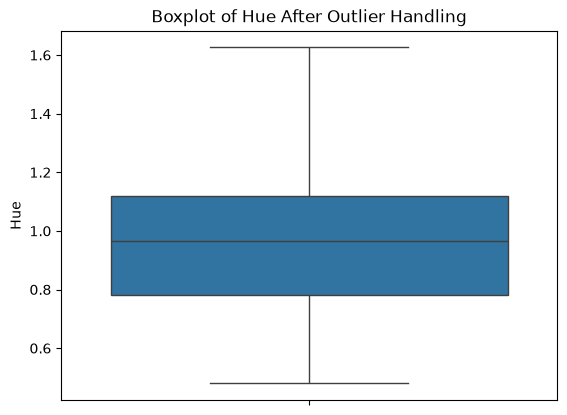

In [43]:
df['Hue'] = df['Hue'].clip(lower=low_lim, upper=upr_lim)
sns.boxplot(df['Hue'])
plt.title('Boxplot of Hue After Outlier Handling')
plt.show()

### Feature Scaling

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)


In [45]:
X_scaled.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.565534,0.240640,-1.182882,2.057111,0.808997,1.034819,-0.659563,1.264740,0.266954,0.366610,1.847920,1.013009
1,0.246290,-0.501728,-0.862176,-2.524956,0.038639,0.568648,0.733629,-0.820719,-0.549904,-0.291923,0.410768,1.113449,0.965242
2,0.196879,0.026948,1.153315,-0.267832,0.113397,0.808997,1.215533,-0.498407,2.199012,0.284696,0.322451,0.788587,1.395148
3,1.691550,-0.346771,0.506837,-0.816862,1.010496,2.491446,1.466525,-0.981875,1.067105,1.225029,-0.428246,1.184071,2.334574
4,0.295700,0.236596,1.913878,0.464208,1.384287,0.808997,0.663351,0.226796,0.420301,-0.318536,0.366610,0.449601,-0.037874


### K-Means Clustering

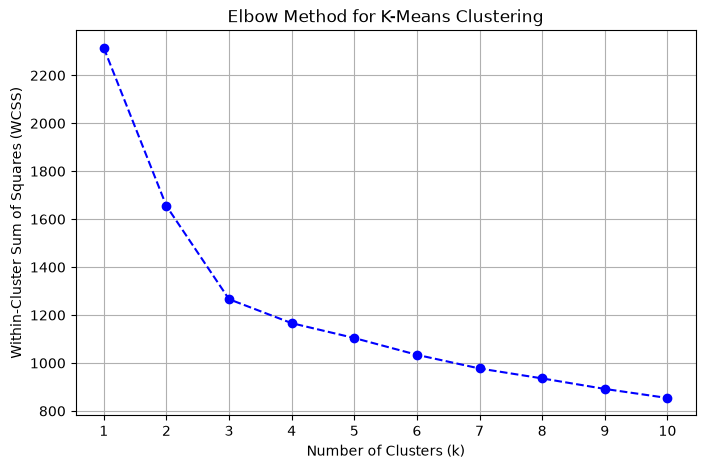

In [46]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Finding Optimum Number of Clusters using Elbow Method (WCSS)
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for K-Means Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


k = 2: Silhouette Score = 0.2683
k = 3: Silhouette Score = 0.2855
k = 4: Silhouette Score = 0.2415
k = 5: Silhouette Score = 0.2319
k = 6: Silhouette Score = 0.1860
k = 7: Silhouette Score = 0.1565
k = 8: Silhouette Score = 0.1530
k = 9: Silhouette Score = 0.1388
k = 10: Silhouette Score = 0.1412


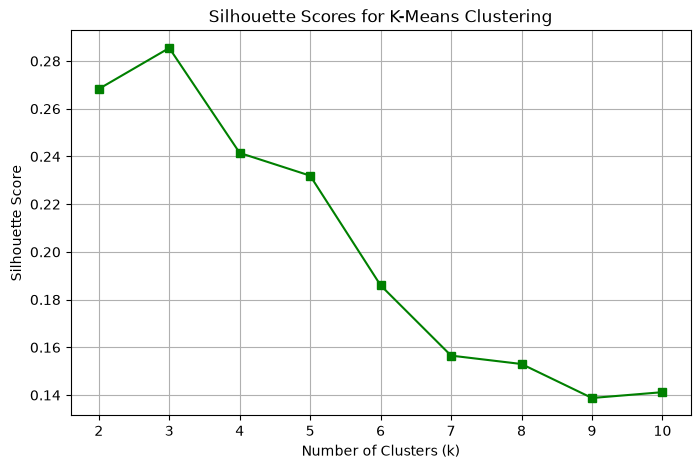

In [47]:
# Evaluating Silhouette Scores for different values of k
sil_scores_km = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores_km.append(score)
    print(f"k = {k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores_km, marker='s', color='green')
plt.title('Silhouette Scores for K-Means Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()


In [48]:
# Model building with optimum number of clusters (k = 3)
optimum_k = 3
kmeans_model = KMeans(n_clusters=optimum_k, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans_model.fit_predict(X_scaled)

# Cluster frequency distribution
print("K-Means Cluster Counts:")
print(pd.Series(y_kmeans).value_counts().sort_index())


K-Means Cluster Counts:
0    65
1    51
2    62
Name: count, dtype: int64


In [49]:
# Performance Evaluation for K-Means
acc_sil_km = silhouette_score(X_scaled, y_kmeans)
acc_db_km = davies_bouldin_score(X_scaled, y_kmeans)

print("K-Means Performance Summary")
print(f"Optimum Clusters     : {optimum_k}")
print(f"Silhouette Score     : {acc_sil_km:.4f}")
print(f"Davies-Bouldin Index : {acc_db_km:.4f}")


K-Means Performance Summary
Optimum Clusters     : 3
Silhouette Score     : 0.2855
Davies-Bouldin Index : 1.3816


### Agglomerative Hierarchical Clustering (AHC)

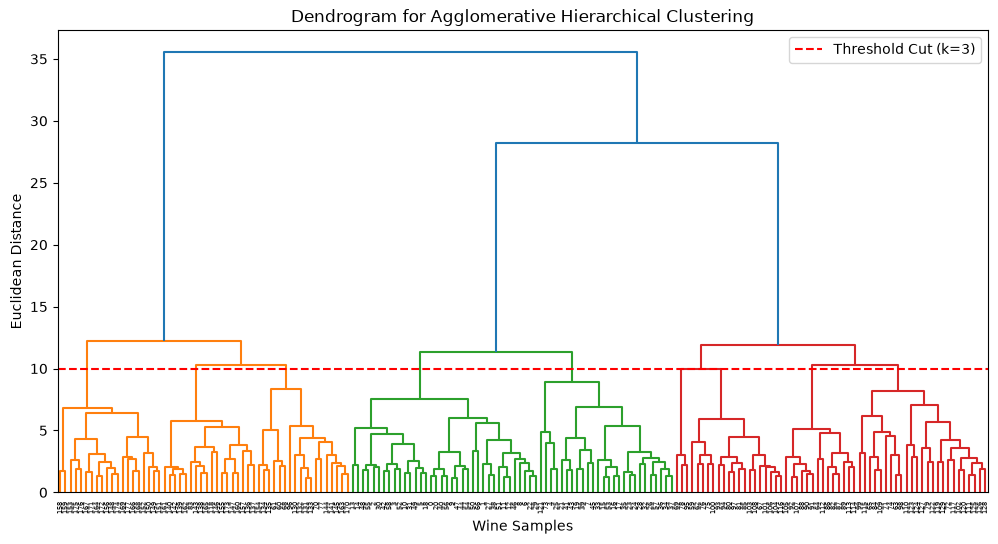

In [50]:
import scipy.cluster.hierarchy as sch

# Plotting Dendrogram using Ward Linkage
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram for Agglomerative Hierarchical Clustering')
plt.xlabel('Wine Samples')
plt.ylabel('Euclidean Distance')
plt.axhline(y=10, color='r', linestyle='--', label='Threshold Cut (k=3)')
plt.legend()
plt.show()


In [51]:
from sklearn.cluster import AgglomerativeClustering

# Silhouette Scores for AHC across different k values
sil_scores_ahc = []
for k in range(2, 11):
    ahc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = ahc.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores_ahc.append(score)
    print(f"k = {k}: Silhouette Score = {score:.4f}")


k = 2: Silhouette Score = 0.2676
k = 3: Silhouette Score = 0.2787
k = 4: Silhouette Score = 0.2172
k = 5: Silhouette Score = 0.1854
k = 6: Silhouette Score = 0.1239
k = 7: Silhouette Score = 0.1254
k = 8: Silhouette Score = 0.1278
k = 9: Silhouette Score = 0.1366
k = 10: Silhouette Score = 0.1303


In [52]:
# Creating AHC Model with optimum number of clusters (k = 3)
optimum_k_ahc = 3
ahc_model = AgglomerativeClustering(n_clusters=optimum_k_ahc, metric='euclidean', linkage='ward')
y_ahc = ahc_model.fit_predict(X_scaled)

# Cluster frequency distribution
print("AHC Cluster Counts:")
print(pd.Series(y_ahc).value_counts().sort_index())


AHC Cluster Counts:
0    56
1    60
2    62
Name: count, dtype: int64


In [53]:
# Performance Evaluation for AHC
acc_sil_ahc = silhouette_score(X_scaled, y_ahc)
acc_db_ahc = davies_bouldin_score(X_scaled, y_ahc)

print("Agglomerative Hierarchical Clustering Performance Summary")
print(f"Optimum Clusters     : {optimum_k_ahc}")
print(f"Silhouette Score     : {acc_sil_ahc:.4f}")
print(f"Davies-Bouldin Index : {acc_db_ahc:.4f}")


Agglomerative Hierarchical Clustering Performance Summary
Optimum Clusters     : 3
Silhouette Score     : 0.2787
Davies-Bouldin Index : 1.3918


### DBSCAN Clustering

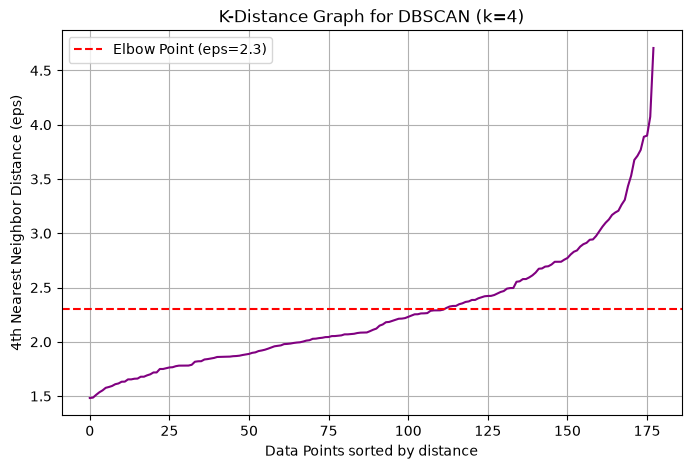

In [54]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# K-distance graph to determine optimum eps parameter (min_samples = 4)
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances, color='purple')
plt.title('K-Distance Graph for DBSCAN (k=4)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('4th Nearest Neighbor Distance (eps)')
plt.axhline(y=2.3, color='r', linestyle='--', label='Elbow Point (eps=2.3)')
plt.legend()
plt.grid(True)
plt.show()


In [55]:
# Building DBSCAN Model with optimum parameters (eps=2.3, min_samples=4)
optimum_eps = 2.3
optimum_min_samples = 4

dbscan_model = DBSCAN(eps=optimum_eps, min_samples=optimum_min_samples)
y_dbscan = dbscan_model.fit_predict(X_scaled)

# Cluster distribution (-1 represents noise points)
print("DBSCAN Cluster Counts (-1 = Noise):")
print(pd.Series(y_dbscan).value_counts().sort_index())


DBSCAN Cluster Counts (-1 = Noise):
-1    37
 0    98
 1    43
Name: count, dtype: int64


In [56]:
# Performance Evaluation for DBSCAN
acc_sil_db = silhouette_score(X_scaled, y_dbscan)
acc_db_db = davies_bouldin_score(X_scaled, y_dbscan)

n_clusters_db = len(set(y_dbscan) - ({-1} if -1 in y_dbscan else set()))
n_noise_db = list(y_dbscan).count(-1)

print("DBSCAN Performance Summary")
print(f"Optimum eps          : {optimum_eps}")
print(f"Optimum min_samples  : {optimum_min_samples}")
print(f"Estimated Clusters   : {n_clusters_db}")
print(f"Noise Points         : {n_noise_db}")
print(f"Silhouette Score     : {acc_sil_db:.4f}")
print(f"Davies-Bouldin Index : {acc_db_db:.4f}")


DBSCAN Performance Summary
Optimum eps          : 2.3
Optimum min_samples  : 4
Estimated Clusters   : 2
Noise Points         : 37
Silhouette Score     : 0.1889
Davies-Bouldin Index : 3.4091


### Principal Component Analysis (PCA)

In [57]:
from sklearn.decomposition import PCA

# Fitting PCA to evaluate explained variance ratio
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cum_variance = np.cumsum(explained_variance)

for i, (var, cum_var) in enumerate(zip(explained_variance, cum_variance), 1):
    print(f"PC{i}: Variance Explained = {var*100:.2f}%, Cumulative = {cum_var*100:.2f}%")


PC1: Variance Explained = 36.48%, Cumulative = 36.48%
PC2: Variance Explained = 19.61%, Cumulative = 56.09%
PC3: Variance Explained = 10.91%, Cumulative = 67.00%
PC4: Variance Explained = 7.06%, Cumulative = 74.06%
PC5: Variance Explained = 6.30%, Cumulative = 80.36%
PC6: Variance Explained = 4.82%, Cumulative = 85.17%
PC7: Variance Explained = 4.03%, Cumulative = 89.20%
PC8: Variance Explained = 2.74%, Cumulative = 91.95%
PC9: Variance Explained = 2.23%, Cumulative = 94.18%
PC10: Variance Explained = 1.93%, Cumulative = 96.11%
PC11: Variance Explained = 1.76%, Cumulative = 97.87%
PC12: Variance Explained = 1.33%, Cumulative = 99.19%
PC13: Variance Explained = 0.81%, Cumulative = 100.00%


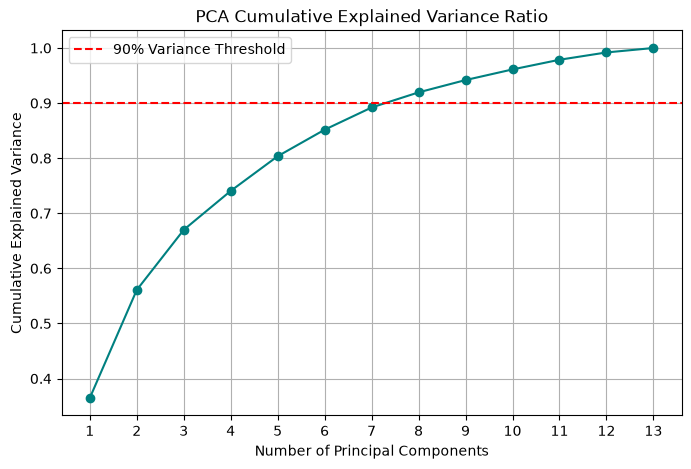

In [58]:
# Plotting Cumulative Explained Variance Ratio
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o', linestyle='-', color='teal')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.title('PCA Cumulative Explained Variance Ratio')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, 14))
plt.legend()
plt.grid(True)
plt.show()


In [59]:
# Transforming dataset to 2 Principal Components for 2D Visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_df.head()


,PC1,PC2
0,3.358147,1.520222
1,2.229215,-0.333261
2,2.540057,1.036953
3,3.781124,2.782566
4,1.016872,0.955225


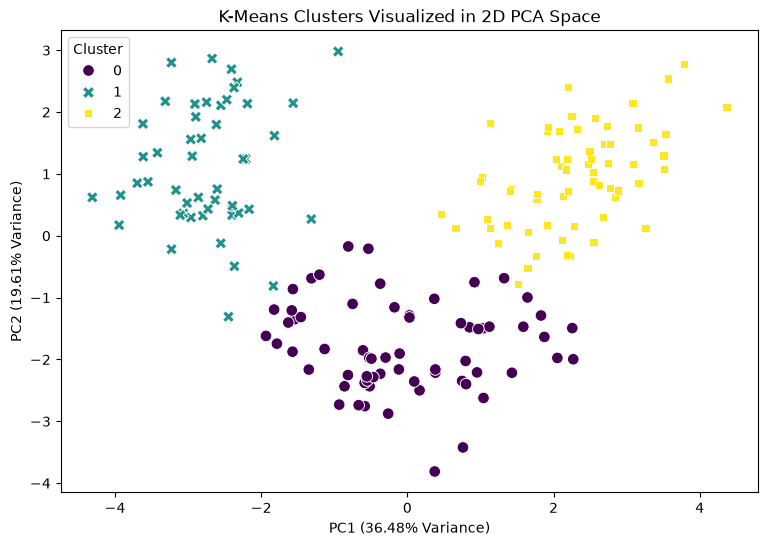

In [60]:
# Visualizing K-Means Clusters in 2D PCA Space
plt.figure(figsize=(9, 6))
sns.scatterplot(x='PC1', y='PC2', hue=y_kmeans, palette='viridis', data=pca_df, s=70, style=y_kmeans)
plt.title('K-Means Clusters Visualized in 2D PCA Space')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.legend(title='Cluster')
plt.show()


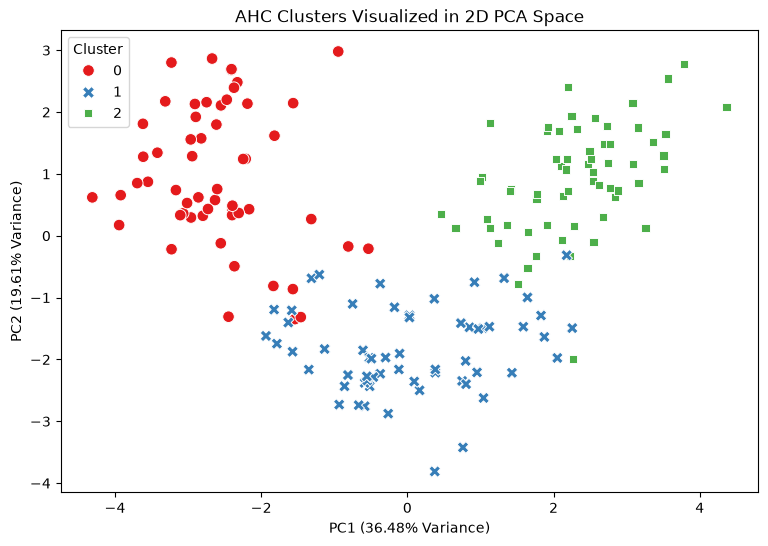

In [61]:
# Visualizing Agglomerative Hierarchical Clusters in 2D PCA Space
plt.figure(figsize=(9, 6))
sns.scatterplot(x='PC1', y='PC2', hue=y_ahc, palette='Set1', data=pca_df, s=70, style=y_ahc)
plt.title('AHC Clusters Visualized in 2D PCA Space')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.legend(title='Cluster')
plt.show()


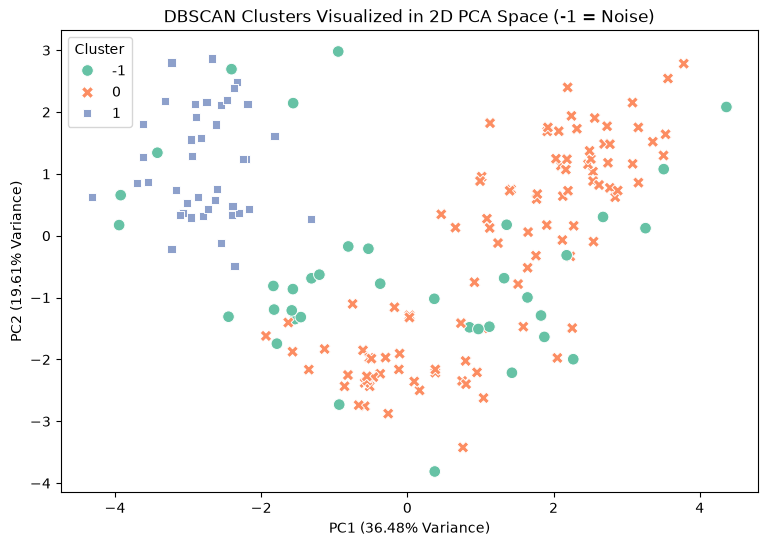

In [62]:
# Visualizing DBSCAN Clusters in 2D PCA Space
plt.figure(figsize=(9, 6))
sns.scatterplot(x='PC1', y='PC2', hue=y_dbscan, palette='Set2', data=pca_df, s=70, style=y_dbscan)
plt.title('DBSCAN Clusters Visualized in 2D PCA Space (-1 = Noise)')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.legend(title='Cluster')
plt.show()


In [63]:
# K-Means Clustering directly on 2D PCA-transformed data
kmeans_pca = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
y_kmeans_pca = kmeans_pca.fit_predict(X_pca_2d)

acc_sil_pca_km = silhouette_score(X_pca_2d, y_kmeans_pca)
acc_db_pca_km = davies_bouldin_score(X_pca_2d, y_kmeans_pca)

print("K-Means on 2D PCA Features Performance Summary")
print(f"Silhouette Score     : {acc_sil_pca_km:.4f}")
print(f"Davies-Bouldin Index : {acc_db_pca_km:.4f}")


K-Means on 2D PCA Features Performance Summary
Silhouette Score     : 0.5613
Davies-Bouldin Index : 0.5983


### Comparison

In [64]:
# Summary comparison table of all clustering models
results = pd.DataFrame({
    'Model': [
        'K-Means Clustering',
        'Agglomerative Hierarchical Clustering (AHC)',
        'DBSCAN Clustering',
        'K-Means on 2D PCA Features'
    ],
    'Optimum Parameters': [
        'k = 3',
        'k = 3 (Ward linkage)',
        'eps = 2.3, min_samples = 4',
        'k = 3 (2 Components)'
    ],
    'Silhouette Score': [acc_sil_km, acc_sil_ahc, acc_sil_db, acc_sil_pca_km],
    'Davies-Bouldin Index': [acc_db_km, acc_db_ahc, acc_db_db, acc_db_pca_km]
})

results


,Model,Optimum Parameters,Silhouette Score,Davies-Bouldin Index
0,K-Means Clustering,k = 3,0.285463,1.381606
1,Agglomerative Hierarchical Clustering (AHC),k = 3 (Ward linkage),0.278700,1.391758
2,DBSCAN Clustering,"eps = 2.3, min_samples = 4",0.188896,3.409128
3,K-Means on 2D PCA Features,k = 3 (2 Components),0.561322,0.598344


In [65]:
# Identifying the best model based on highest Silhouette Score
best_sil_row = results.loc[results['Silhouette Score'].idxmax()]
print(f"Best model: {best_sil_row['Model']} (Silhouette Score: {best_sil_row['Silhouette Score']:.4f})")


Best model: K-Means on 2D PCA Features (Silhouette Score: 0.5613)
